# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
# Load cleaned data created in the cleaning notebook
analysis_df = pd.read_csv("data/AviationData_cleaned.csv")

# Look at first rows
display(analysis_df.head())

/var/folders/xj/3fqt44g11p73jkrkp149njbm0000gn/T/ipykernel_14311/1962705470.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  analysis_df = pd.read_csv("data/AviationData_cleaned.csv")


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Uninjured,Weather.Condition,Report.Status,Publication.Date,Event.Year,serious_fatal_injuries,total_people_onboard_est,serious_fatal_rate,was_destroyed,Make_Model
0,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,0.0,IMC,Probable Cause,02-05-2011,1983,2.0,2.0,1.0,1,PIPER | PA-28-140
1,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,4.0,VMC,Probable Cause,17-10-2016,1983,1.0,5.0,0.2,0,DE HAVILLAND | DHC-6
2,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,1.0,VMC,Probable Cause,05-05-2011,1983,0.0,1.0,0.0,0,BEECH | C35
3,20001214X45339,Accident,LAX84LA110,1983-12-22,"SANTA ROSA ISLAND, CA",United States,NaN,NaN,NaN,PRIVATE,...,1.0,VMC,Probable Cause,01-02-2016,1983,0.0,1.0,0.0,0,CESSNA | 180K
4,20001214X38957,Accident,ATL84LA120,1984-03-14,"MYRTLE BEACH, SC",United States,NaN,NaN,CRE,GRAND STRAND,...,1.0,VMC,Probable Cause,24-09-2018,1984,0.0,1.0,0.0,0,BEECH | 99


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# Passenger threshold requested by prompt
passenger_threshold = 20

# Keep rows where passenger estimate is known
analysis_df = analysis_df.dropna(subset=["total_people_onboard_est", "serious_fatal_rate", "Make"]).copy()

# Create small vs large airplane groups
small_df = analysis_df[analysis_df["total_people_onboard_est"] < passenger_threshold].copy()
large_df = analysis_df[analysis_df["total_people_onboard_est"] >= passenger_threshold].copy()

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

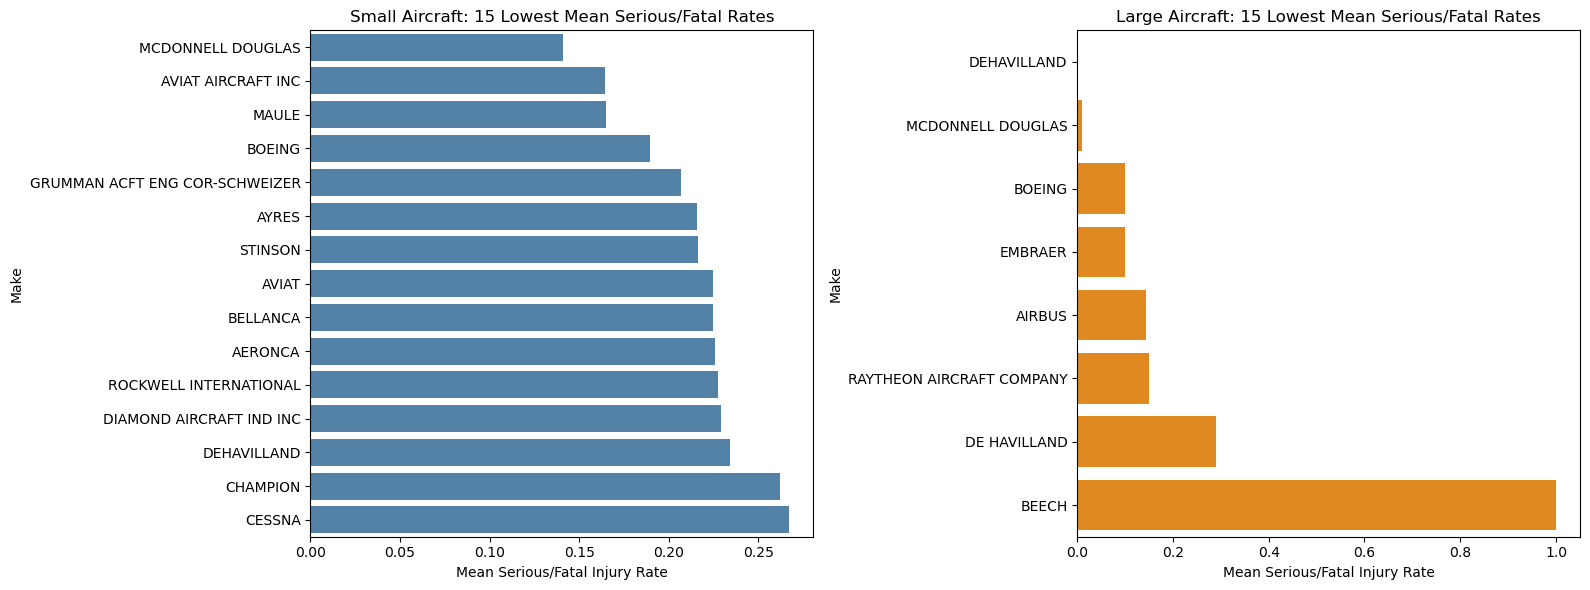

,mean_injury_rate,n
Make,,
MCDONNELL DOUGLAS,0.141071,20
AVIAT AIRCRAFT INC,0.164474,76
MAULE,0.164806,215
BOEING,0.189450,188
GRUMMAN ACFT ENG COR-SCHWEIZER,0.206897,58
AYRES,0.215686,51
STINSON,0.216408,129
AVIAT,0.224638,69
BELLANCA,0.224654,217


,mean_injury_rate,n
Make,,
DEHAVILLAND,0.000000,1
MCDONNELL DOUGLAS,0.010917,38
BOEING,0.099316,297
EMBRAER,0.099474,51
AIRBUS,0.143900,68
RAYTHEON AIRCRAFT COMPANY,0.150000,1
DE HAVILLAND,0.289526,8
BEECH,1.000000,2


In [5]:
# Calculate mean injury rate by Make for small airplanes
small_make_stats = (
    small_df.groupby("Make")
    .agg(mean_injury_rate=("serious_fatal_rate", "mean"), n=("Make", "size"))
    .sort_values("mean_injury_rate")
)

# Calculate mean injury rate by Make for large airplanes
large_make_stats = (
    large_df.groupby("Make")
    .agg(mean_injury_rate=("serious_fatal_rate", "mean"), n=("Make", "size"))
    .sort_values("mean_injury_rate")
)

# Keep lowest 15 makes in each group
small_best15 = small_make_stats.head(15)
large_best15 = large_make_stats.head(15)

# Plot side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

sns.barplot(data=small_best15.reset_index(), x="mean_injury_rate", y="Make", ax=axes[0], color="steelblue")
axes[0].set_title("Small Aircraft: 15 Lowest Mean Serious/Fatal Rates")
axes[0].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[0].set_ylabel("Make")

sns.barplot(data=large_best15.reset_index(), x="mean_injury_rate", y="Make", ax=axes[1], color="darkorange")
axes[1].set_title("Large Aircraft: 15 Lowest Mean Serious/Fatal Rates")
axes[1].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

display(small_best15)
display(large_best15)

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

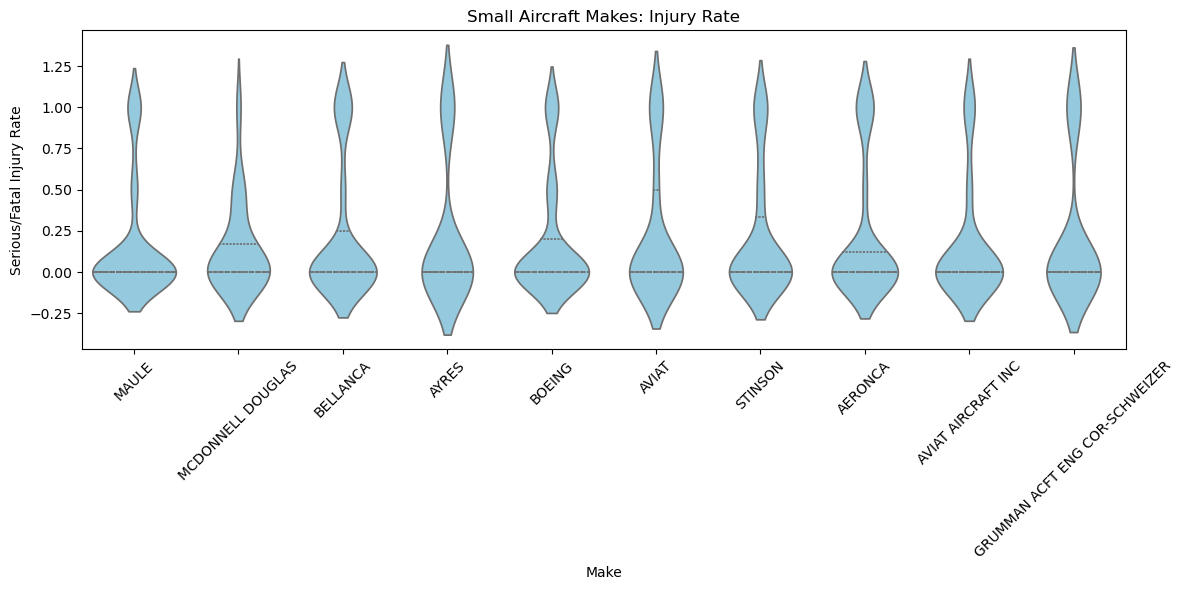

In [6]:
small_best10_makes = small_best15.head(10).index
small_plot_df = small_df[small_df["Make"].isin(small_best10_makes)].copy()

plt.figure(figsize=(12, 6))
sns.violinplot(data=small_plot_df, x="Make", y="serious_fatal_rate", inner="quartile", color="skyblue")
plt.title("Small Aircraft Makes: Injury Rate")
plt.xlabel("Make")
plt.ylabel("Serious/Fatal Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

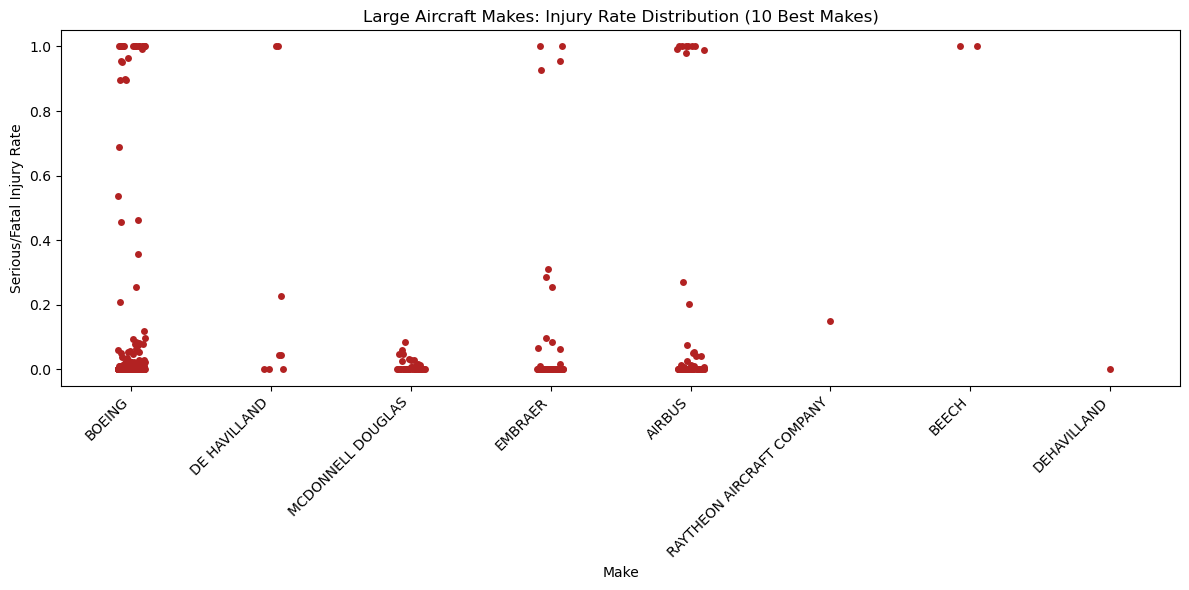

In [7]:
large_best10_makes = large_best15.head(10).index
large_plot_df = large_df[large_df["Make"].isin(large_best10_makes)].copy()

plt.figure(figsize=(12, 6))
sns.stripplot(data=large_plot_df, x="Make", y="serious_fatal_rate", color="firebrick")
plt.title("Large Aircraft Makes: Injury Rate Distribution (10 Best Makes)")
plt.xlabel("Make")
plt.ylabel("Serious/Fatal Injury Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

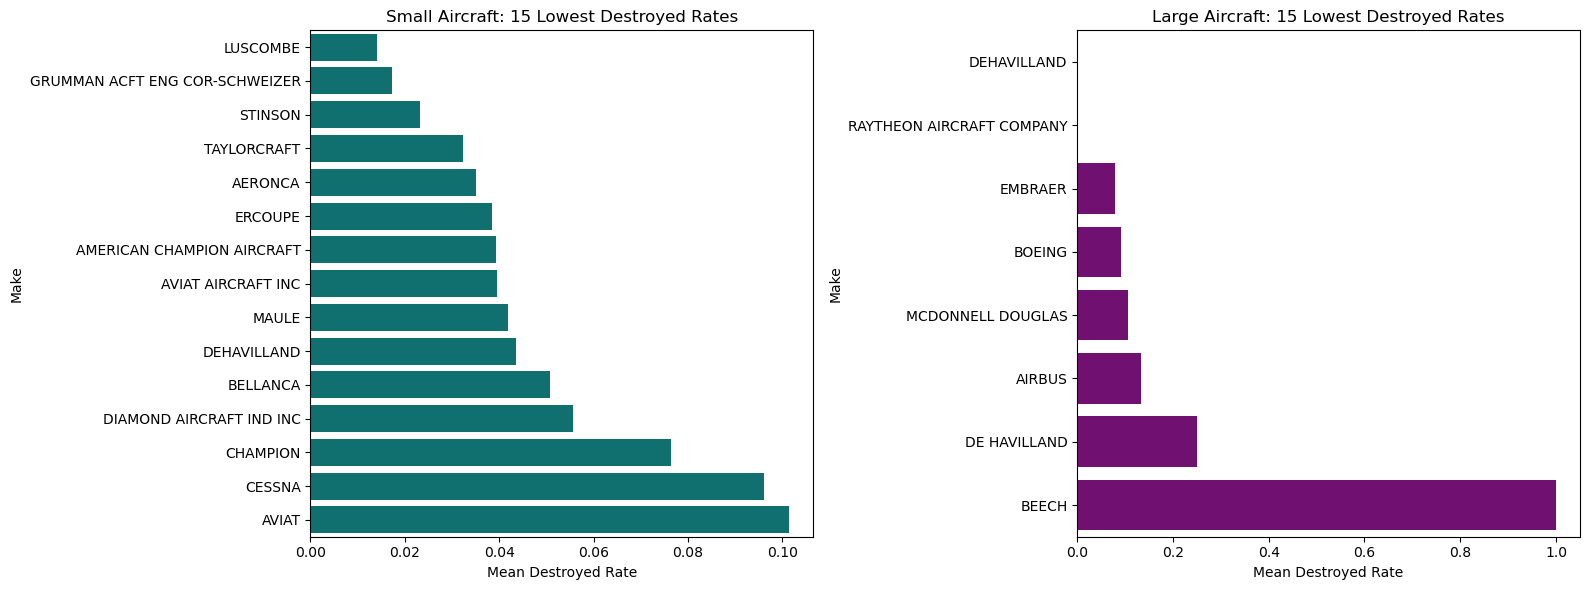

,mean_destroyed_rate,n
Make,,
LUSCOMBE,0.014184,141
GRUMMAN ACFT ENG COR-SCHWEIZER,0.017241,58
STINSON,0.023256,129
TAYLORCRAFT,0.032258,93
AERONCA,0.035000,200
ERCOUPE,0.038462,52
AMERICAN CHAMPION AIRCRAFT,0.039216,51
AVIAT AIRCRAFT INC,0.039474,76
MAULE,0.041860,215


,mean_destroyed_rate,n
Make,,
DEHAVILLAND,0.000000,1
RAYTHEON AIRCRAFT COMPANY,0.000000,1
EMBRAER,0.078431,51
BOEING,0.090909,297
MCDONNELL DOUGLAS,0.105263,38
AIRBUS,0.132353,68
DE HAVILLAND,0.250000,8
BEECH,1.000000,2


In [9]:
# Aircraft destruction rate by Make (small airplanes)
small_destroy_stats = (
    small_df.groupby("Make")
    .agg(mean_destroyed_rate=("was_destroyed", "mean"), n=("Make", "size"))
    .sort_values("mean_destroyed_rate")
)

# Aircraft destruction rate by Make (large airplanes)
large_destroy_stats = (
    large_df.groupby("Make")
    .agg(mean_destroyed_rate=("was_destroyed", "mean"), n=("Make", "size"))
    .sort_values("mean_destroyed_rate")
)

small_destroy_best15 = small_destroy_stats.head(15)
large_destroy_best15 = large_destroy_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=small_destroy_best15.reset_index(), x="mean_destroyed_rate", y="Make", ax=axes[0], color="teal")
axes[0].set_title("Small Aircraft: 15 Lowest Destroyed Rates")
axes[0].set_xlabel("Mean Destroyed Rate")
axes[0].set_ylabel("Make")

sns.barplot(data=large_destroy_best15.reset_index(), x="mean_destroyed_rate", y="Make", ax=axes[1], color="purple")
axes[1].set_title("Large Aircraft: 15 Lowest Destroyed Rates")
axes[1].set_xlabel("Mean Destroyed Rate")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

display(small_destroy_best15)
display(large_destroy_best15)

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
small_rank = small_best15.reset_index()[["Make", "mean_injury_rate"]].copy()
small_rank["injury_rank"] = small_rank["mean_injury_rate"].rank(method="dense")
small_rank = small_rank.merge(
    small_destroy_best15.reset_index()[["Make", "mean_destroyed_rate"]],
    on="Make",
    how="inner"
)
small_rank["destroy_rank"] = small_rank["mean_destroyed_rate"].rank(method="dense")
small_rank["combined_score"] = small_rank["injury_rank"] + small_rank["destroy_rank"]
small_recommendations = small_rank.sort_values("combined_score").head(5)

large_rank = large_best15.reset_index()[["Make", "mean_injury_rate"]].copy()
large_rank["injury_rank"] = large_rank["mean_injury_rate"].rank(method="dense")
large_rank = large_rank.merge(
    large_destroy_best15.reset_index()[["Make", "mean_destroyed_rate"]],
    on="Make",
    how="inner"
)
large_rank["destroy_rank"] = large_rank["mean_destroyed_rate"].rank(method="dense")
large_rank["combined_score"] = large_rank["injury_rank"] + large_rank["destroy_rank"]
large_recommendations = large_rank.sort_values("combined_score").head(5)

display(small_recommendations)
display(large_recommendations)


Small aircraft make recommendations (lower is better):


,Make,mean_injury_rate,injury_rank,mean_destroyed_rate,destroy_rank,combined_score
0,AVIAT AIRCRAFT INC,0.164474,2.0,0.039474,4.0,6.0
2,GRUMMAN ACFT ENG COR-SCHWEIZER,0.206897,5.0,0.017241,1.0,6.0
1,MAULE,0.164806,3.0,0.041860,5.0,8.0
3,STINSON,0.216408,7.0,0.023256,2.0,9.0
6,AERONCA,0.225833,10.0,0.035000,3.0,13.0


Large aircraft make recommendations (lower is better):


,Make,mean_injury_rate,injury_rank,mean_destroyed_rate,destroy_rank,combined_score
0,DEHAVILLAND,0.000000,1.0,0.000000,1.0,2.0
1,MCDONNELL DOUGLAS,0.010917,2.0,0.105263,4.0,6.0
2,BOEING,0.099316,3.0,0.090909,3.0,6.0
3,EMBRAER,0.099474,4.0,0.078431,2.0,6.0
5,RAYTHEON AIRCRAFT COMPANY,0.150000,6.0,0.000000,1.0,7.0


Discussion:
- Lower mean injury and destruction rates suggest safer outcomes in this historical data.
- We only kept makes with enough observations (>= 20) for better statistical stability.
- Final choices should also include business factors like cost, availability, and mission profile.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

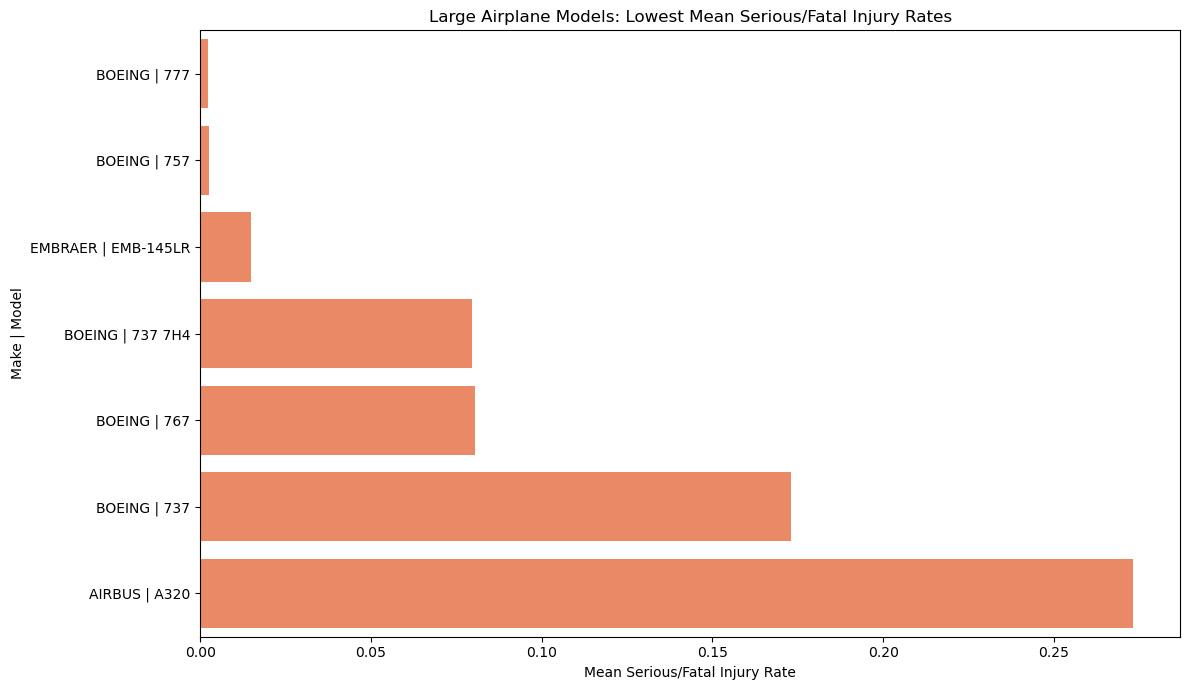

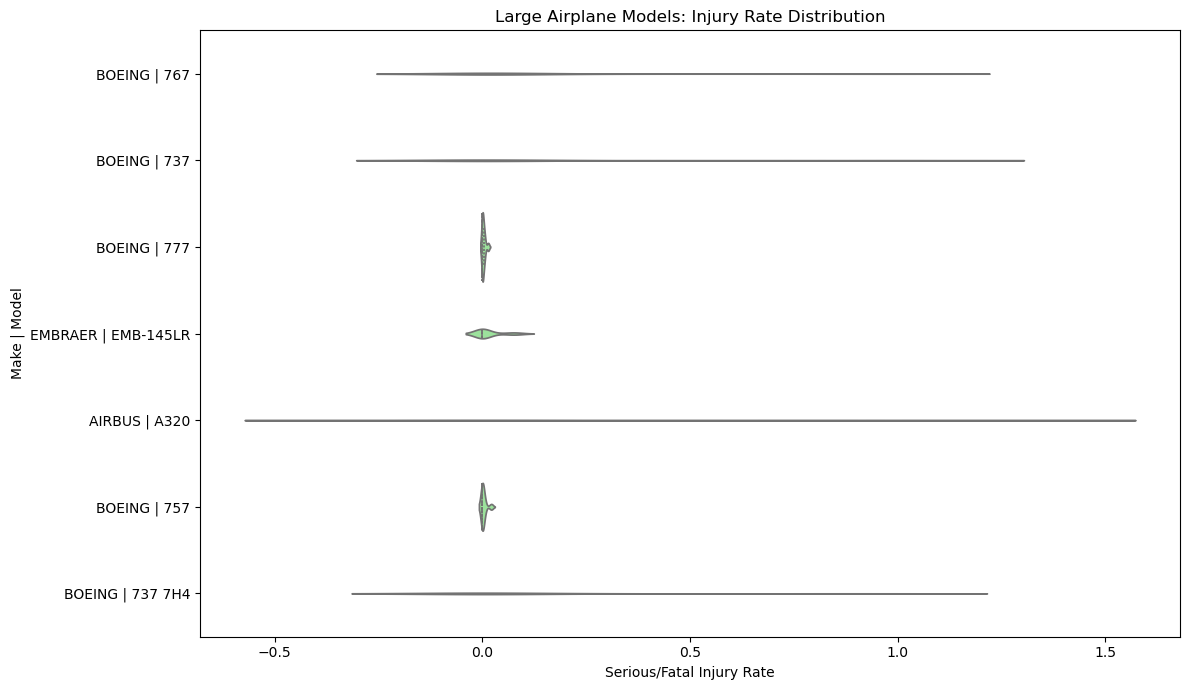

,mean_injury_rate,n
Make_Model,,
BOEING | 777,0.002258,12
BOEING | 757,0.002651,10
EMBRAER | EMB-145LR,0.015000,10
BOEING | 737 7H4,0.079474,12
BOEING | 767,0.080531,18
BOEING | 737,0.173053,76
AIRBUS | A320,0.273252,11


In [11]:
# Large-aircraft model analysis (require at least 10 examples per model)
min_model_samples = 10

large_model_stats = (
    large_df.groupby("Make_Model")
    .agg(mean_injury_rate=("serious_fatal_rate", "mean"), n=("Make_Model", "size"))
    .query("n >= @min_model_samples")
    .sort_values("mean_injury_rate")
)

large_model_best15 = large_model_stats.head(15)

# Plot mean serious/fatal injury rate for larger plane models
plt.figure(figsize=(12, 7))
sns.barplot(data=large_model_best15.reset_index(), x="mean_injury_rate", y="Make_Model", color="coral")
plt.title("Large Airplane Models: Lowest Mean Serious/Fatal Injury Rates")
plt.xlabel("Mean Serious/Fatal Injury Rate")
plt.ylabel("Make | Model")
plt.tight_layout()
plt.show()

# Distribution plot (violin) for these models
plot_models = large_model_best15.index
large_model_plot_df = large_df[large_df["Make_Model"].isin(plot_models)].copy()

plt.figure(figsize=(12, 7))
sns.violinplot(data=large_model_plot_df, x="serious_fatal_rate", y="Make_Model", inner="quartile", color="lightgreen")
plt.title("Large Airplane Models: Injury Rate Distribution")
plt.xlabel("Serious/Fatal Injury Rate")
plt.ylabel("Make | Model")
plt.tight_layout()
plt.show()

display(large_model_best15)

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

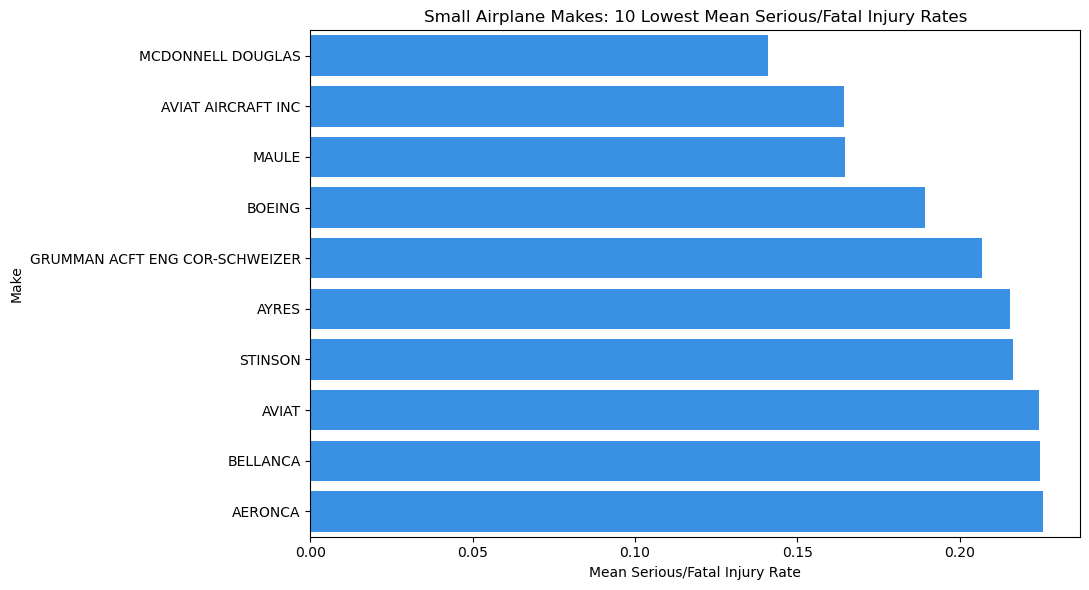

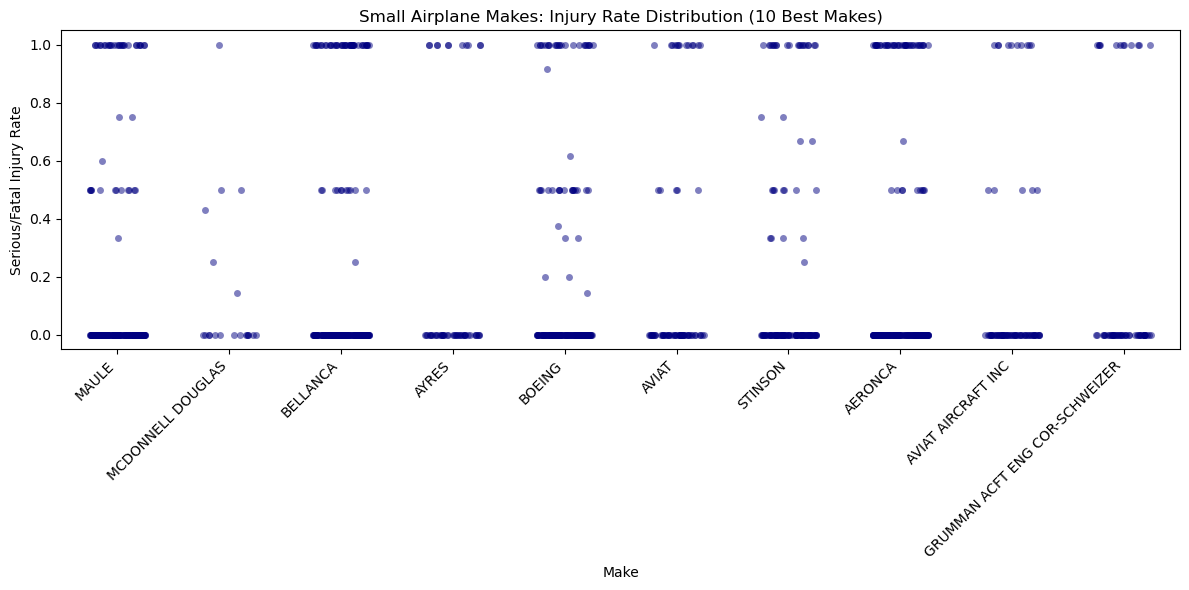

,mean_injury_rate,n
Make,,
MCDONNELL DOUGLAS,0.141071,20
AVIAT AIRCRAFT INC,0.164474,76
MAULE,0.164806,215
BOEING,0.189450,188
GRUMMAN ACFT ENG COR-SCHWEIZER,0.206897,58
AYRES,0.215686,51
STINSON,0.216408,129
AVIAT,0.224638,69
BELLANCA,0.224654,217


In [ ]:
# Small-aircraft make analysis
small_make_best10 = small_make_stats.head(10)

# Mean rate plot
plt.figure(figsize=(11, 6))
sns.barplot(data=small_make_best10.reset_index(), x="mean_injury_rate", y="Make", color="dodgerblue")
plt.title("Small Airplane Makes: 10 Lowest Mean Serious/Fatal Injury Rates")
plt.xlabel("Mean Serious/Fatal Injury Rate")
plt.ylabel("Make")
plt.tight_layout()
plt.show()

# Distribution plot for these makes
small_make_plot_df = small_df[small_df["Make"].isin(small_make_best10.index)].copy()

plt.figure(figsize=(12, 6))
sns.stripplot(data=small_make_plot_df, x="Make", y="serious_fatal_rate", jitter=0.25, alpha=0.5, color="navy")
plt.title("Small Airplane Makes: Injury Rate Distribution (10 Best Makes)")
plt.xlabel("Make")
plt.ylabel("Serious/Fatal Injury Rate")
plt.tight_layout()
plt.show()

display(small_make_best10)

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
# Large airplane models with enough samples show several options with very low mean serious/fatal injury rates.
# Small airplane recommendations are presented at the make level, limited to the 10 best mean injury rates.
# Distribution plots help verify whether low means come from consistently low outcomes or from wide spread data
# In practice, prefer options that are low-risk in both mean values and distribution spread.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Weather condition summary:


,mean_injury_rate,mean_destroyed_rate,n
Weather.Condition,,,
VMC,0.237495,0.072391,13952
IMC,0.647461,0.363741,866


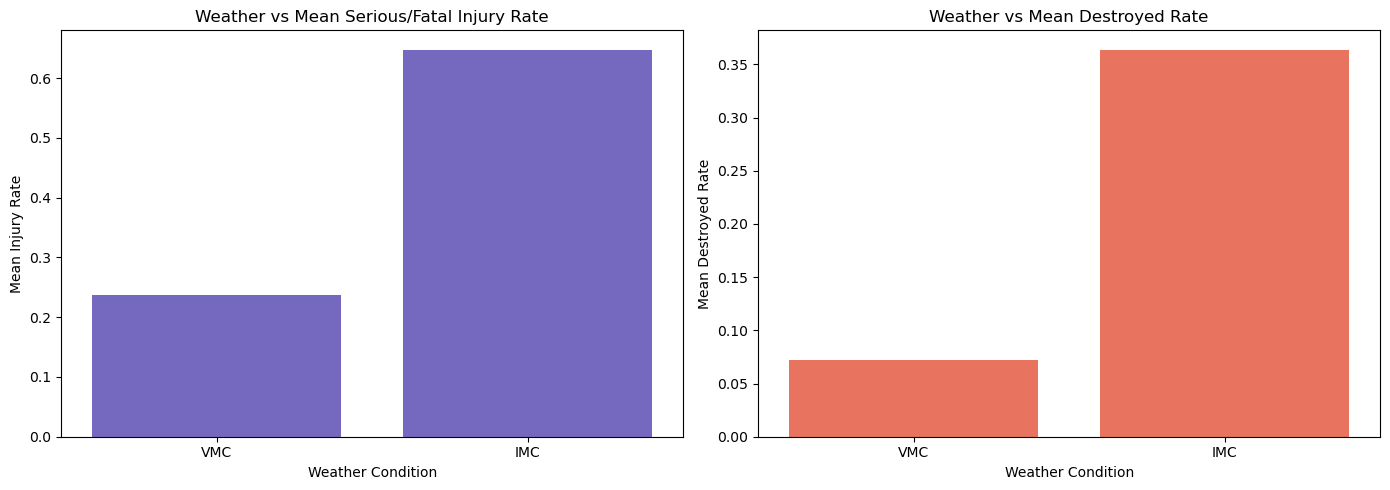

KeyError: 'Broad.phase.of.flight'